## MULTIPLE LINEAR REGRESSION

#### Assignment Task:

Your task is to perform a multiple linear regression analysis to predict the price of Toyota corolla based on the given attributes.
    
Dataset Description:

The dataset consists of the following variables:

Age: Age in years

KM: Accumulated Kilometers on odometer

FuelType: Fuel Type (Petrol, Diesel, CNG)

HP: Horse Power

Automatic: Automatic ( (Yes=1, No=0)

CC: Cylinder Volume in cubic centimeters

Doors: Number of doors

Weight: Weight in Kilograms

Quarterly_Tax: 

Price: Offer Price in EUROs


#### Tasks:

##### 1.Perform exploratory data analysis (EDA) to gain insights into the dataset. Provide visualizations and summary statistics of the variables. Pre-process the data to apply the MLR.

First 5 Rows:
    Price  Age_08_04     KM Fuel_Type  HP  Automatic    cc  Doors  Cylinders  \
0  13500         23  46986    Diesel  90          0  2000      3          4   
1  13750         23  72937    Diesel  90          0  2000      3          4   
2  13950         24  41711    Diesel  90          0  2000      3          4   
3  14950         26  48000    Diesel  90          0  2000      3          4   
4  13750         30  38500    Diesel  90          0  2000      3          4   

   Gears  Weight  
0      5    1165  
1      5    1165  
2      5    1165  
3      5    1165  
4      5    1170  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 

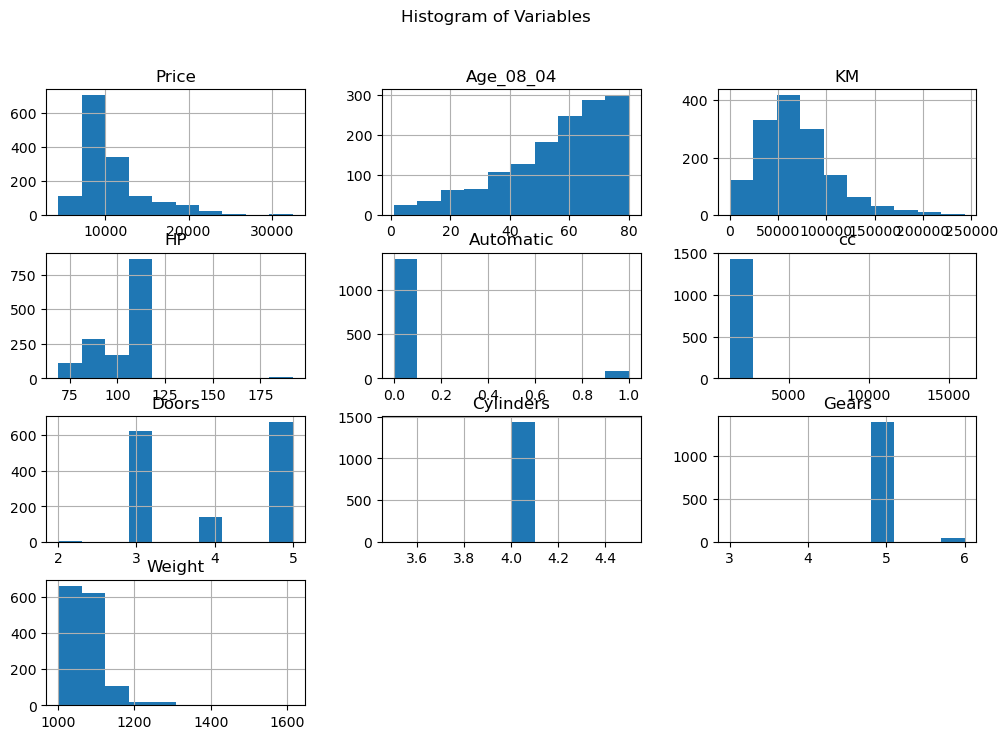

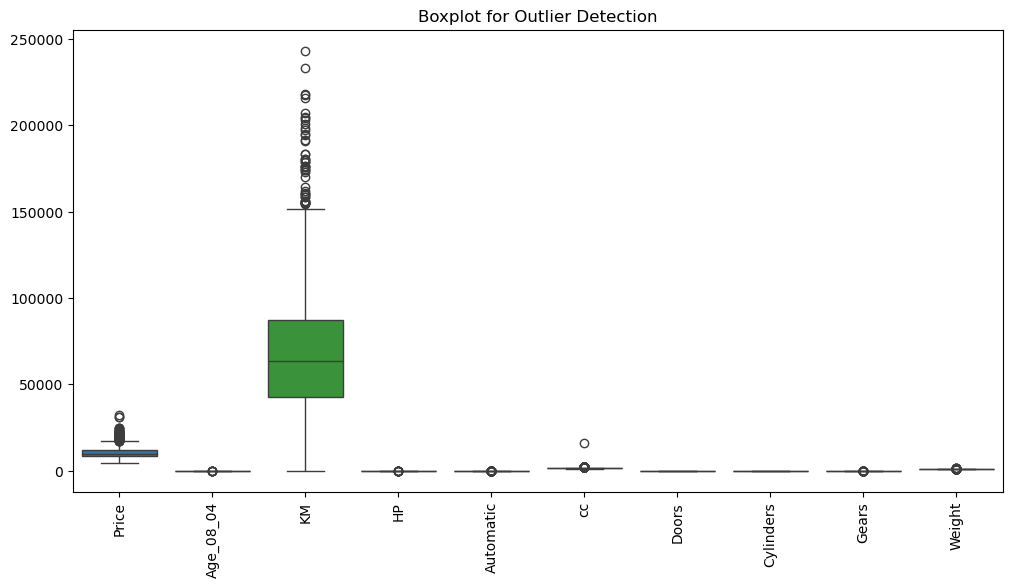

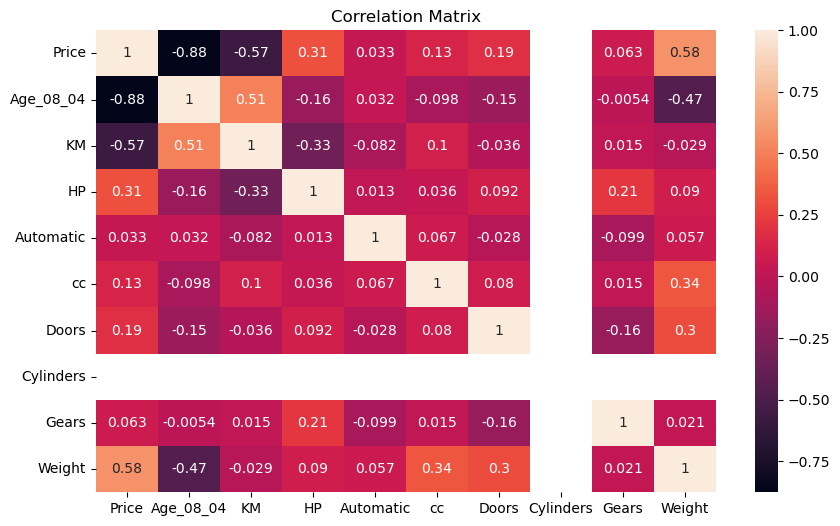


EDA and Preprocessing Completed Successfully!


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

df = pd.read_csv(r"C:\Users\Rakshitha\Downloads\Multiple Linear Regression\ToyotaCorolla - MLR.csv")

print("First 5 Rows:\n", df.head())

print("\nDataset Info:")
df.info()

print("\nSummary Statistics:\n", df.describe())

print("\nMissing Values:\n", df.isnull().sum())

# Drop missing values (if any)
df = df.dropna()

# Histograms (distribution)
df.hist(figsize=(12,8))
plt.suptitle("Histogram of Variables")
plt.show()

# Boxplot (outlier detection)
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.title("Boxplot for Outlier Detection")
plt.show()

# Correlation Heatmap (numeric only)
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include=['int64','float64']).corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

# Clean column names
df.columns = df.columns.str.strip()

# Automatically encode all categorical columns
df = pd.get_dummies(df, drop_first=True)

# Define features and target
X = df.drop("Price", axis=1)
y = df["Price"]

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nEDA and Preprocessing Completed Successfully!")

##### 2.Split the dataset into training and testing sets (e.g., 80% training, 20% testing).

In [4]:
from sklearn.model_selection import train_test_split

# Features and target
X = df.drop("Price", axis=1)
y = df["Price"]

# Split dataset (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Output shapes
print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)
print("Training Target Shape:", y_train.shape)
print("Testing Target Shape:", y_test.shape)

Training Features Shape: (1148, 11)
Testing Features Shape: (288, 11)
Training Target Shape: (1148,)
Testing Target Shape: (288,)


##### 3.Build a multiple linear regression model using the training dataset. Interpret the coefficients of the model. Build a minimum of 3 different models.

In [7]:
from sklearn.linear_model import LinearRegression
import pandas as pd

# Model 1: All Features
model1 = LinearRegression()
model1.fit(X_train, y_train)

print("\nModel 1 Coefficients:")
print(pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model1.coef_
}))

# Model 2: First 4 Features 
features2 = X_train.columns[:4]   # automatically pick first 4 columns

model2 = LinearRegression()
model2.fit(X_train[features2], y_train)

print("\nModel 2 Coefficients:")
print(pd.DataFrame({
    "Feature": features2,
    "Coefficient": model2.coef_
}))

#  Model 3: Next 5 Features 
features3 = X_train.columns[4:9]  # automatically pick next set

model3 = LinearRegression()
model3.fit(X_train[features3], y_train)

print("\nModel 3 Coefficients:")
print(pd.DataFrame({
    "Feature": features3,
    "Coefficient": model3.coef_
}))


Model 1 Coefficients:
             Feature   Coefficient
0          Age_08_04 -1.208305e+02
1                 KM -1.623141e-02
2                 HP  1.403948e+01
3          Automatic  1.488309e+02
4                 cc -3.037219e-02
5              Doors -6.031097e+01
6          Cylinders  6.536993e-13
7              Gears  5.516007e+02
8             Weight  2.588496e+01
9   Fuel_Type_Diesel -6.854876e+01
10  Fuel_Type_Petrol  1.370809e+03

Model 2 Coefficients:
     Feature  Coefficient
0  Age_08_04  -154.668914
1         KM    -0.010663
2         HP    34.850331
3  Automatic   786.787962

Model 3 Coefficients:
     Feature   Coefficient
0         cc -6.048395e-01
1      Doors  6.854912e+01
2  Cylinders  9.663381e-13
3      Gears  8.843893e+02
4     Weight  4.284964e+01


##### 4.Evaluate the performance of the model using appropriate evaluation metrics on the testing dataset.

In [9]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Model 1 Evaluation 
y_pred1 = model1.predict(X_test)

print("Model 1 Performance:")
print("MSE:", mean_squared_error(y_test, y_pred1))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred1)))
print("R2 Score:", r2_score(y_test, y_pred1))
print("-"*40)

# Model 2 Evaluation 
y_pred2 = model2.predict(X_test[features2])

print("Model 2 Performance:")
print("MSE:", mean_squared_error(y_test, y_pred2))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred2)))
print("R2 Score:", r2_score(y_test, y_pred2))
print("-"*40)

# Model 3 Evaluation 
y_pred3 = model3.predict(X_test[features3])

print("Model 3 Performance:")
print("MSE:", mean_squared_error(y_test, y_pred3))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred3)))
print("R2 Score:", r2_score(y_test, y_pred3))

Model 1 Performance:
MSE: 2203043.8231437
RMSE: 1484.2654153296505
R2 Score: 0.8348888040611084
----------------------------------------
Model 2 Performance:
MSE: 2516980.25176151
RMSE: 1586.4993702367203
R2 Score: 0.8113602574959727
----------------------------------------
Model 3 Performance:
MSE: 8792949.196299657
RMSE: 2965.2907439743
R2 Score: 0.3409961516066251


##### 5.Apply Lasso and Ridge methods on the model.

In [11]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Ridge Regression 
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)

print("Ridge Regression Performance:")
print("MSE:", mean_squared_error(y_test, y_pred_ridge))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_ridge)))
print("R2 Score:", r2_score(y_test, y_pred_ridge))
print("-"*40)

# Lasso Regression 
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

y_pred_lasso = lasso.predict(X_test)

print("Lasso Regression Performance:")
print("MSE:", mean_squared_error(y_test, y_pred_lasso))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lasso)))
print("R2 Score:", r2_score(y_test, y_pred_lasso))

Ridge Regression Performance:
MSE: 2199746.370233335
RMSE: 1483.1541963778868
R2 Score: 0.835135937771234
----------------------------------------
Lasso Regression Performance:
MSE: 2202270.260024682
RMSE: 1484.0048045827486
R2 Score: 0.8349467801805


#### Interview Questions:

##### 1.What is Normalization & Standardization and how is it helpful?

##### Normalization:

Normalization is a data scaling technique used to transform feature values into a fixed range between 0 and 1.

Why it is helpful:

Removes differences in feature scales.

Improves performance of algorithms that depend on distance calculations.

Helps models converge faster.


##### Standardization:

Standardization is a scaling method that transforms data so that it has:

- Mean = 0

- Standard Deviation = 1

Why it is helpful:

Ensures all variables contribute equally to the model.

Prevents features with large values from dominating the model.

Improves numerical stability.


Both methods help machine learning models perform better by bringing features to the same scale.

##### 2.What techniques can be used to address multicollinearity in multiple linear regression?

Techniques to address multicollinearity in Multiple Linear Regression:

##### ->

1. Remove highly correlated variables  using a correlation matrix.
    
2. Check Variance Inflation Factor (VIF) and remove variables with high VIF.
    
3. Use Ridge Regression to reduce coefficient values.
    
4. Use Lasso Regression for feature selection.
    
5. Apply Principal Component Analysis (PCA) to transform correlated variables into uncorrelated components.